## General stuff
Guassian:\
$\phi(x) = e^{-\|x\|^2}$

Image function:\
$ f : \mathbb{R}^2 \to \mathbb{R}$

Approximation:\
$ \hat{f}(x) = \sum^n_{i=0}\alpha_i (g_i \triangleright \phi)(y) = \sum^n_{i=0}\alpha_i (\psi(v_i) \triangleright \phi)(y)$

Lie group (dim 6):\
$G = \text{Aff}^+(2)$

Group action on $R^2$:\
For $g \in G, y \in R^2$ then $g \triangleright y = (x, A) \triangleright y := Ay + x$

For $f : \mathbb{R}^2 \to \mathbb{R}$ then $(g \triangleright f)(y) := f(g^{-1} \triangleright y)$ 

Parameter space (dim 6):\
$V = \mathbb{R}^2 \times \text{SO}(2) \times \text{SNM}(2)$

Mapping:\
$\psi : V \to G$\
$\psi(L, X, Y) = (L, \exp(X)\exp(Y))$

For $X = \begin{pmatrix}
0 & b \\
-b & 0
\end{pmatrix}$ then $\exp(X) = \begin{pmatrix}
\cos(b) & \sin(b) \\
-\sin(b) & \cos(b)
\end{pmatrix}$

For
$
Y=\begin{pmatrix}a & b \\ b & c\end{pmatrix},
$
define
$
m=\tfrac{a+c}{2}, \quad 
B = Y - mI = \begin{pmatrix}\tfrac{a-c}{2} & b \\[4pt] b & -\tfrac{a-c}{2}\end{pmatrix}, \quad 
s=\sqrt{b^{2}+\left(\tfrac{a-c}{2}\right)^{2}}.
$

Then
$
\exp(Y) \;=\; e^{\,m}\!\left( \cosh(s)\,I + \frac{\sinh(s)}{s}\,B \right).
$

Loss:\
$\mathcal{L} = \|f-\hat{f}\|_{L^2}$

In [102]:
import torch
import numpy as np
import math

In [103]:
# Group actions

def group_action(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.einsum('bgjk,bgk->bgj', A, y) + x

def group_action_inv(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.einsum('bgjk,bgk->bgj', torch.linalg.inv(A), y - x)

def group_action_func(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor, f: callable) -> torch.Tensor:
    y_inv = group_action_inv(x, A, y)
    return f(y_inv)

In [104]:
# Mapping from parametric space to lie group

# Map exp of the theta of a 2x2 anti symmetric matrix to explicit
def exp_SO(theta: torch.Tensor) -> torch.Tensor:
    return torch.stack([torch.stack([torch.cos(theta), -torch.sin(theta)]),
                         torch.stack([torch.sin(theta), torch.cos(theta)])]).permute(2, 3, 0, 1)

# Map exp of 2x2 symmetric matrix to explicit
def exp_SNM(a: torch.Tensor, b: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    m = 0.5 * (a + c)

    # Define B = A - mI
    B00 = 0.5 * (a - c)
    B01 = b
    B10 = b
    B11 = -0.5 * (a - c)

    # Compute s = sqrt(b^2 + ((a-c)/2)^2)
    s = torch.sqrt(b**2 + (0.5 * (a - c))**2)

    # Handle s=0 case with safe division
    sinhc = torch.where(s > 1e-12, torch.sinh(s) / s, torch.ones_like(s))

    # exp(A) = exp(m) * (cosh(s) * I + (sinh(s)/s) * B)
    expm = torch.zeros(m.shape + (2, 2), dtype=m.dtype, device=a.device)
    expm[..., 0, 0] = torch.cosh(s) + sinhc * B00
    expm[..., 0, 1] = sinhc * B01
    expm[..., 1, 0] = sinhc * B10
    expm[..., 1, 1] = torch.cosh(s) + sinhc * B11

    return torch.exp(m)[..., None, None] * expm




In [105]:
# gaussian

def gaussian(y: torch.Tensor):
    norm = torch.linalg.vector_norm(y, dim=2)
    return torch.exp(-1 * torch.pow(norm, 2))

def f_hat(w: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    # calc all parameters
    alpha = w[0]
    a = w[1]
    b = w[2]
    c = w[3]
    theta = w[4]
    x1 = w[5]
    x2 = w[6]

    Y = exp_SNM(a, b, c)

    A = torch.einsum('bgij,bgjk->bgik', exp_SO(theta), Y)
    x = torch.stack([x1, x2]).permute(1, 2, 0)
    # print((torch.sigmoid(alpha) * group_action_func(x, A, y, gaussian)).size())
    return (torch.sigmoid(alpha) * group_action_func(x, A, y, gaussian)).sum(dim=0)


torch.Size([1, 1])
torch.Size([1, 1, 2, 2])
torch.Size([1, 1, 2])
tensor([[0.0547]])


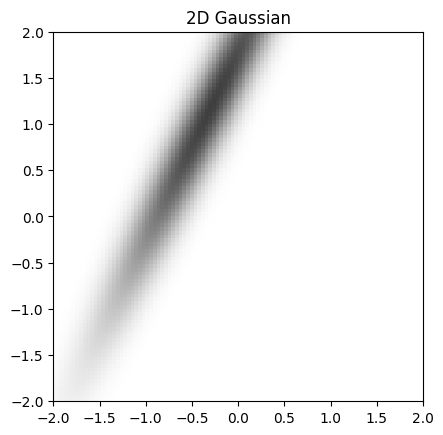

In [106]:

# plot 2D image of gaussian function

import matplotlib.pyplot as plt

# Create a grid of points
xv, yv = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
points = np.stack([xv, yv], axis=-1)  # shape (100, 100, 2)

x = torch.tensor([[[-0.2805,1.2112]]])
# 1.1102,  0.7595, -0.3787, -1.3284,  0.3944, -0.2805,  1.2112

a = torch.tensor([[0.7595]])
b = torch.tensor([[-0.3787]])
c = torch.tensor([[-1.3284]])
print(c.size())
theta = torch.tensor([[1.2944]])
print((exp_SO(theta) @ exp_SNM(a,b,c)).size())
print(x.size())

print(group_action_func(x, exp_SO(theta) @ exp_SNM(a,b,c), torch.tensor([points[0, 0]], dtype=torch.float), gaussian))


# Evaluate gaussian at each point
gauss_img = np.zeros((100, 100))
for i in range(100):
	for j in range(100):
		gauss_img[i, j] = torch.sigmoid(torch.tensor(1.1102))*group_action_func(x, exp_SO(theta) @ exp_SNM(a,b,c), torch.tensor([points[i, j]], dtype=torch.float), gaussian).sum()

plt.title("2D Gaussian")
plt.imshow(1 - gauss_img, extent=[-2, 2, -2, 2], origin='lower', cmap='gray', vmin=0, vmax=1)
plt.show()

In [119]:

torch.autograd.set_detect_anomaly(False)

device = torch.device("cuda:0")

def train(learning_rate: float, epochs: int, batches: int, guassians: int, target: torch.Tensor):
    # Prepare training data as a batch for vectorized computation
    inputs = torch.stack([torch.tensor([i, j], dtype=torch.float, device=device) for i in range(-2, 3) for j in range(-2, 3)])  # shape (25, 2)
    targets = torch.stack([target.flatten()]*batches)  # shape (25, )

    w = torch.randn(7, guassians, batches, requires_grad=True, device=device)

    for epoch in range(epochs):
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}")
            
        # Vectorized forward pass
        preds = torch.stack([
            f_hat(w, torch.stack([x] * batches)) for x in inputs
        ]).permute(1, 0) 

        eps = 1e-18 # counteract floating point inprecision
        loss = torch.sqrt(torch.sum((targets - preds)**2, 1)  + eps).mean()
        loss.backward()
        with torch.no_grad():
            # if (epoch + 1) % 10 == 0:
            #     print(w.grad.sum(1))
            w -= learning_rate * w.grad
        w.grad.zero_()

    preds = torch.stack([f_hat(w, torch.stack([x] * batches)) for x in inputs]).permute(1, 0)
    loss = torch.sqrt(torch.sum((targets - preds)**2, 1))

    return loss, w

In [108]:
# plot 2D image of gaussian function
def plot_image(w: torch.Tensor, resolution=25):
    w = w.to(torch.device("cpu"))
    # Create a grid of points
    xv, yv = np.meshgrid(np.linspace(-2, 2, resolution), np.linspace(-2, 2, resolution))
    points = torch.tensor(np.stack([xv, yv], axis=-1), dtype=torch.float)  # shape (100, 100, 2)

    # Evaluate gaussian at each point
    gauss_img = np.zeros((resolution, resolution))
    for i in range(0, resolution):
        for j in range(0, resolution):
            gauss_img[i, j] = f_hat(w.unsqueeze(1).permute(0,2,1), torch.stack([points[i, j]]))

    plt.title("2D Gaussian")
    plt.imshow(1-gauss_img, origin='lower', cmap='gray', vmin=0, vmax=1)
    plt.show()

In [112]:
learning_rate = 1
epochs = 100
batches = 50

# create a 4x4 tensor with all the same value a=0.3
a = 0.5
output_z = torch.full((5, 5), a, device=device)

loss, w = train(learning_rate, epochs, batches, 1, output_z)

min_index = torch.argmin(loss)



Epoch 10/100
tensor([[-1.9160e-03, -2.2026e-03, -9.7535e-04, -1.0874e-04, -2.6220e-03,
         -1.9380e-04, -3.7370e-04, -1.2134e-03, -2.4665e-04, -6.8248e-04,
         -2.5690e-04, -1.8953e-03, -2.0110e-03, -6.1209e-04,  2.6974e-05,
          2.4628e-03, -8.5180e-04, -1.9329e-04, -1.2816e-03, -3.4333e-04,
         -1.6460e-04, -1.4405e-03, -1.1037e-03, -2.1116e-03, -2.6280e-03,
         -3.3399e-04, -1.4266e-03,  4.0558e-04, -1.1402e-03, -1.3630e-05,
         -5.2504e-04, -9.7481e-04, -1.4842e-04, -1.3350e-04, -3.2677e-03,
         -5.9536e-04, -7.7009e-04, -5.8688e-04, -2.5167e-04, -1.2926e-03,
         -3.1185e-03, -3.2114e-04, -5.1968e-04, -6.2007e-04, -8.1785e-03,
         -2.4734e-03, -3.3911e-04, -5.0125e-06, -3.7233e-04, -5.9119e-04],
        [-4.6937e-03, -4.3404e-03, -1.9284e-03, -3.5837e-04, -3.4050e-03,
         -1.5013e-03, -8.4863e-04, -3.0352e-03, -7.5586e-04, -6.0540e-03,
         -3.0862e-03, -1.2588e-03, -2.8135e-03, -8.9316e-03,  2.1270e-03,
         -5.0179e-03, -2

In [113]:
print(loss)
inputs = torch.stack([torch.tensor([i, j], dtype=torch.float, device=device) for i in range(-2, 3) for j in range(-2, 3)])
preds = torch.stack([
    f_hat(w, torch.stack([x] * batches)) for x in inputs
]).permute(1, 0) 
print(preds)

tensor([1.0206, 1.4612, 2.3222, 2.4560, 0.6110, 2.3972, 2.3484, 2.3192, 2.2489,
        2.4272, 1.5511, 2.3225, 1.6261, 0.7659, 2.3477, 0.1911, 2.2847, 0.6982,
        2.3267, 2.3215, 2.4066, 2.2237, 2.2189, 1.8576, 1.7038, 2.4442, 2.1880,
        1.2944, 0.6111, 2.3514, 2.4482, 2.3802, 2.2725, 2.3969, 0.3402, 2.4093,
        1.9947, 2.3876, 2.0363, 0.4726, 1.1779, 2.4127, 2.0951, 2.4036, 0.2010,
        0.3129, 2.3291, 2.4891, 2.3806, 2.1516], device='cuda:0',
       grad_fn=<SqrtBackward0>)
tensor([[2.6172e-01, 3.8565e-01, 4.4638e-01,  ..., 1.9417e-01, 1.6923e-01,
         1.1586e-01],
        [1.0058e-01, 2.1571e-01, 2.7362e-01,  ..., 2.0091e-01, 3.7588e-01,
         4.1593e-01],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [2.5742e-35, 2.6514e-41, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [1.2795e-15, 7.5444e-05, 1.5558e-01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
    

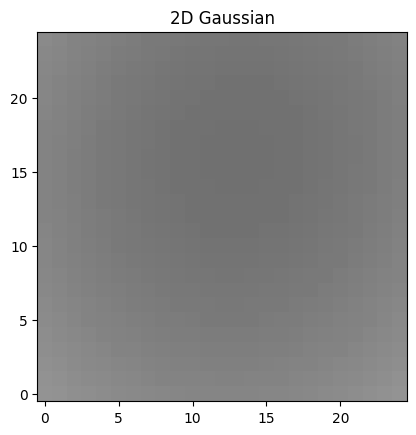

In [114]:
plot_image(w[:, :,min_index], 25)

In [120]:
learning_rate = 0.1
epochs = 100
batches = 100
guassians = 3

# create a 5x5 with a black stripe in the middle
output_z = torch.stack([torch.tensor([0]*5), torch.tensor([0]*5), torch.tensor([1]*5), torch.tensor([0]*5), torch.tensor([0]*5)]).to(device)

print(output_z)

loss, w = train(learning_rate, epochs, batches, guassians, output_z)

print(loss)
min_index = torch.argmin(loss)

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], device='cuda:0')
Epoch 10/100
Epoch 20/100
Epoch 30/100
Epoch 40/100
Epoch 50/100
Epoch 60/100
Epoch 70/100
Epoch 80/100
Epoch 90/100
Epoch 100/100
tensor([2.1569, 1.5832, 1.9932, 2.0471, 1.7077, 2.1157, 2.1277, 2.0466, 2.0329,
        2.0856, 1.8702, 1.8527, 2.3694, 2.1304, 2.4393, 2.0218, 1.8166, 1.1382,
        2.0993, 2.1594, 2.3186, 1.9252, 1.3410, 2.4183, 1.9300, 1.9864, 1.6921,
        2.0162, 2.1302, 2.3831, 2.2069, 2.1128, 1.7121, 0.9208, 0.8575, 2.1431,
        1.8730, 2.1083, 1.7485, 2.1996, 1.7888, 1.6949, 2.0119, 1.5850, 2.3660,
        2.4031, 2.1710, 2.1920, 1.9624, 2.0699, 2.0469, 1.9278, 2.0253, 2.3960,
        1.9312, 2.3466, 1.7707, 2.1481, 1.9668, 1.4268, 2.2889, 2.1711, 1.9553,
        2.4235, 1.9502, 1.9069, 1.7539, 1.7531, 1.5417, 2.1010, 2.1459, 1.2453,
        1.7602, 2.0808, 2.1589, 2.1389, 2.1669, 2.4447, 2.1977, 2.0509, 2.0695,
      

tensor(0.8575, device='cuda:0', grad_fn=<SelectBackward0>)


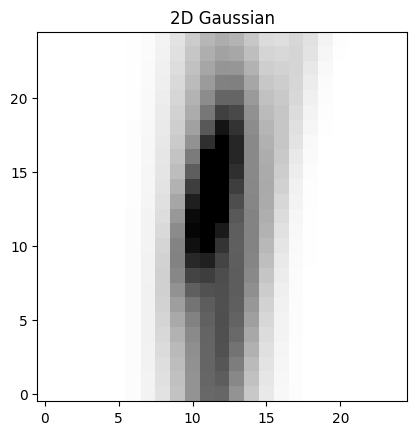

In [121]:
print(loss[min_index])

plot_image(w[:, :, min_index], 25)

In [21]:
learning_rate = 1
epochs = 100
batches = 100

# create a 4x4 tensor with all the same value a=0.3
output_z = torch.stack([torch.tensor([1]*5), torch.tensor([1]*5), torch.tensor([1]*5), torch.tensor([0]*5), torch.tensor([0]*5)]).to(device)

print(output_z)

loss, w = train(learning_rate, epochs, batches, output_z)

print(loss)
min_index = torch.argmin(loss)

tensor([[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], device='cuda:0')
Epoch 10/100
tensor([-0.0751, -0.1100, -0.0061, -0.1178,  0.0199,  0.0682,  0.0133],
       device='cuda:0')
Epoch 20/100
tensor([-0.0827, -0.1108, -0.0050, -0.1264,  0.0203,  0.0685, -0.0025],
       device='cuda:0')
Epoch 30/100
tensor([-0.0891, -0.1116, -0.0035, -0.1345,  0.0174,  0.0624, -0.0012],
       device='cuda:0')
Epoch 40/100
tensor([-0.0950, -0.1141, -0.0038, -0.1375,  0.0218,  0.0731, -0.0011],
       device='cuda:0')
Epoch 50/100
tensor([-0.1003, -0.1161, -0.0021, -0.1422,  0.0214,  0.0776, -0.0014],
       device='cuda:0')
Epoch 60/100
tensor([-1.0554e-01, -1.1816e-01, -7.6081e-05, -1.4701e-01,  2.0014e-02,
         8.1131e-02, -3.7289e-05], device='cuda:0')
Epoch 70/100
tensor([-0.1108, -0.1198,  0.0023, -0.1517,  0.0199,  0.0843,  0.0012],
       device='cuda:0')
Epoch 80/100
tensor([-0.1164, -0.1219,  0.0045, -0.1560,  0.0176,

tensor([[ 0.9026,  1.9928,  0.5076,  1.0702,  1.1386, -1.1887, -0.3549]],
       grad_fn=<StackBackward0>)


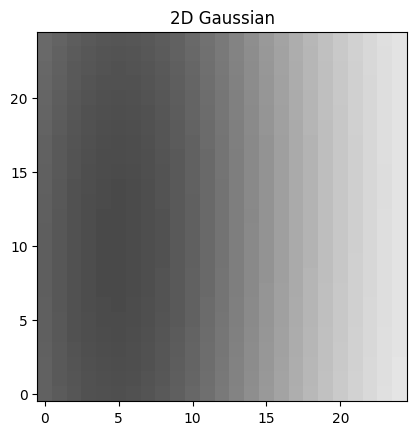

In [22]:
plot_image(w[:, min_index], 25)